In [1]:
import pandas as pd

df = pd.read_csv("results.csv")
df

,index,raw_value,sorted_value,exact,mse
0,1,11190076,11173388,11184812,23906098.56
1,2,11186820,11173740,11184812,23906098.56
2,3,11183348,11175452,11184812,23906098.56
3,4,11188076,11175492,11184812,23906098.56
4,5,11182612,11175612,11184812,23906098.56
...,...,...,...,...,...
95,96,11186556,11193116,11184812,23906098.56
96,97,11182324,11196540,11184812,23906098.56
97,98,11186564,11196604,11184812,23906098.56
98,99,11187132,11197700,11184812,23906098.56


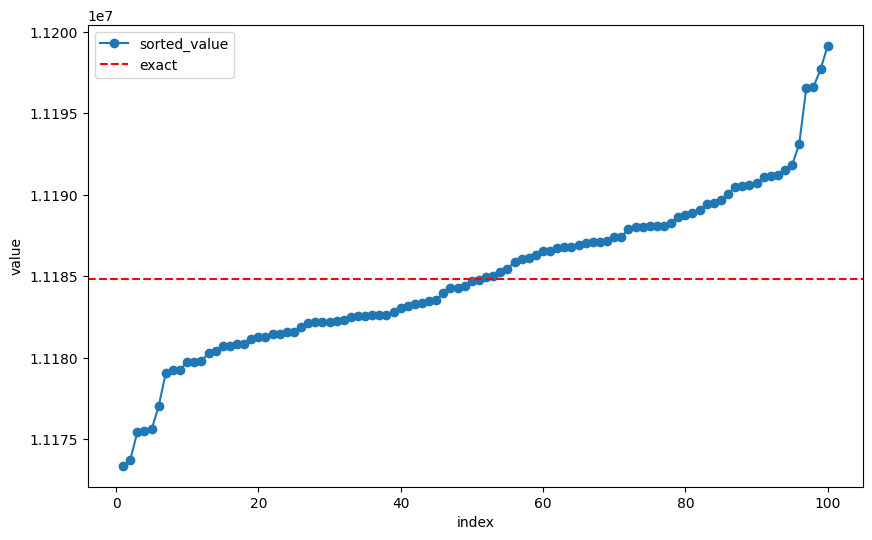

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['index'], df['sorted_value'], marker='o', linestyle='-', label='sorted_value')
plt.axhline(y=df['exact'].iloc[0], color='r', linestyle='--', label='exact')
plt.xlabel('index')
plt.ylabel('value')
plt.legend()
plt.show()

In [10]:
# Split raw_value into groups of 11 elements
raw_values = df['raw_value'].values
groups = {f'G_{i+1}': raw_values[i*group_size:(i+1)*group_size] for i in range(num_groups)}
groups

{'G_1': array([11190076, 11186820, 11183348, 11188076, 11182612, 11183060,
        11181884, 11180860, 11179732, 11182204, 11184388]),
 'G_2': array([11190708, 11182244, 11182140, 11182212, 11179244, 11183548,
        11196604, 11182652, 11188060, 11187132, 11182540]),
 'G_3': array([11179092, 11185444, 11187412, 11188740, 11187052, 11186052,
        11179276, 11181484, 11182636, 11189684, 11196540]),
 'G_4': array([11183484, 11187876, 11179804, 11183284, 11190484, 11197700,
        11182540, 11188084, 11189412, 11191084, 11190596]),
 'G_5': array([11177044, 11181180, 11184772, 11193116, 11191532, 11180756,
        11184940, 11179740, 11186108, 11180292, 11186332]),
 'G_6': array([11183172, 11191220, 11184700, 11199140, 11190564, 11185900,
        11186748, 11182172, 11180452, 11182820, 11181268]),
 'G_7': array([11173388, 11191812, 11189492, 11188036, 11188876, 11175492,
        11191156, 11181452, 11186772, 11189076, 11181572]),
 'G_8': array([11184284, 11175452, 11184996, 11184300, 

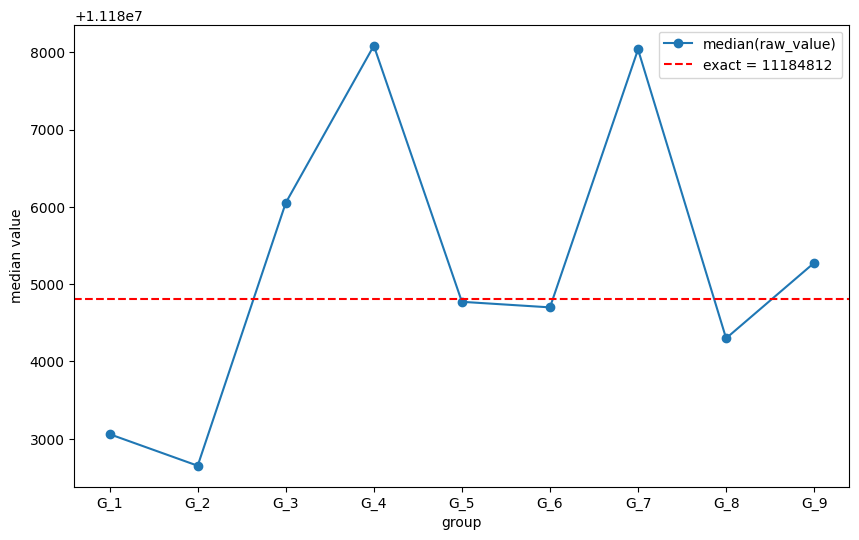

In [ ]:
# Compute medians per grouping and plot like the first figure
if 'groups' in globals():
    group_labels = list(groups.keys())
    medians = [pd.Series(values).median() for values in groups.values()]
else:
    group_size = globals().get('group_size', 11)
    raw_values = df['raw_value'].values
    num_groups = len(raw_values) // group_size
    group_labels = [f'G_{i+1}' for i in range(num_groups)]
    medians = [pd.Series(raw_values[i*group_size:(i+1)*group_size]).median() for i in range(num_groups)]

exact_value = df['exact'].iloc[0]

plt.figure(figsize=(10, 6))
plt.plot(group_labels, medians, marker='o', linestyle='-', label='median(raw_value)')
plt.axhline(y=exact_value, color='r', linestyle='--', label=f'exact')
plt.xlabel('group')
plt.ylabel('median value')
plt.legend()
plt.show()
